In [4]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [5]:
import os
os.makedirs('/Users/mukundtyagi/Desktop/Formula1/f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('/Users/mukundtyagi/Desktop/Formula1/f1_cache')

In [6]:
races = [
    (2022, 'Bahrain'), (2022, 'Australia'), (2022, 'Monaco'),
    (2022, 'Britain'), (2022, 'Italy'), (2022, 'Singapore'), (2022, 'Abu Dhabi'),
    (2023, 'Bahrain'), (2023, 'Australia'), (2023, 'Monaco'),
    (2023, 'Britain'), (2023, 'Italy'), (2023, 'Singapore'), (2023, 'Abu Dhabi'),
    (2024, 'Bahrain'), (2024, 'Australia'), (2024, 'Monaco'),
    (2024, 'Britain'), (2024, 'Italy'), (2024, 'Singapore'), (2024, 'Abu Dhabi'),
]



all_laps_list = []
for i, j in races:
    session = fastf1.get_session(i, j, 'R')
    session.load(laps=True, telemetry=False, weather=True, messages=False)
    laps = session.laps.copy()  # first get the data
    laps['Race'] = j            # then add columns
    laps['Year'] = i
    all_laps_list.append(laps)

all_laps_df = pd.concat(all_laps_list, ignore_index=True)
print(all_laps_df.shape)
print(all_laps_df['Race'].unique())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

(22490, 33)
['Bahrain' 'Australia' 'Monaco' 'Britain' 'Italy' 'Singapore' 'Abu Dhabi']


In [7]:
print(all_laps_df.groupby('Year')['Race'].count())


Year
2022    7197
2023    7748
2024    7545
Name: Race, dtype: int64


In [8]:
all_laps_df.to_csv('/Users/mukundtyagi/Desktop/Formula1/data/raw_laps.csv', index=False)
print("Saved!")

Saved!


In [9]:
df = pd.read_csv('/Users/mukundtyagi/Desktop/Formula1/data/raw_laps.csv')
print(df.shape)
print(df.columns.tolist())


(22490, 33)
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'Race', 'Year']


In [10]:
df.isnull().sum()


Time                      0
Driver                    0
DriverNumber              0
LapTime                 372
LapNumber                 0
Stint                     0
PitOutTime            21713
PitInTime             21713
Sector1Time             483
Sector2Time              57
Sector3Time             161
Sector1SessionTime      527
Sector2SessionTime       57
Sector3SessionTime      161
SpeedI1                  50
SpeedI2                  50
SpeedFL                 827
SpeedST                  52
IsPersonalBest           38
Compound                 35
TyreLife                161
FreshTyre                 0
Team                      0
LapStartTime              0
LapStartDate          22490
TrackStatus               0
Position                 50
Deleted               22490
DeletedReason         22490
FastF1Generated           0
IsAccurate                0
Race                      0
Year                      0
dtype: int64

In [11]:
# Drop columns that are either all null, leakage risks, or irrelevant to strategy
cols_to_drop = [
    'Deleted', 'DeletedReason', 'LapStartDate',  # all null, useless
    'IsPersonalBest', 'FastF1Generated',           # not relevant to lap time prediction
    'PitOutTime', 'PitInTime',                     # mostly null, not a model feature
    'Sector1SessionTime', 'Sector2SessionTime',    # cumulative session time, not useful
    'Sector3SessionTime',
    'Time', 'LapStartTime',                        # raw timestamps, not useful as features
    'DriverNumber',                                # Driver name already captures this
    'TrackStatus'                                  # too granular, not consistent across seasons
]

df = df.drop(columns=cols_to_drop)

# Keep only laps fastf1 marked as accurate - removes formation laps, SC laps etc
df = df[df['IsAccurate'] == True]

# Drop rows where our key features or target variable are missing
df = df.dropna(subset=['LapTime', 'Compound', 'TyreLife', 'SpeedFL', 'SpeedI1', 'SpeedI2', 'SpeedST'])

print(df.shape)

(19394, 19)


In [13]:
df['LapTime'] = pd.to_timedelta(df['LapTime'])
df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()
print(df['LapTimeSeconds'].describe())

count    19394.000000
mean        91.199503
std          9.029109
min         74.165000
25%         84.402250
50%         90.544500
75%         97.672000
max        149.321000
Name: LapTimeSeconds, dtype: float64


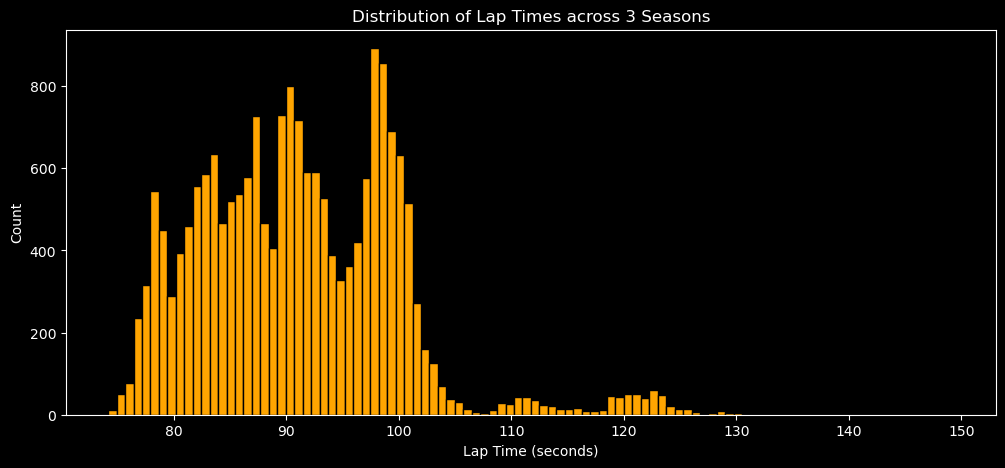

In [14]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['LapTimeSeconds'], bins=100, color='orange', edgecolor='black')
ax.set_xlabel('Lap Time (seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Lap Times across 3 Seasons')
plt.show()

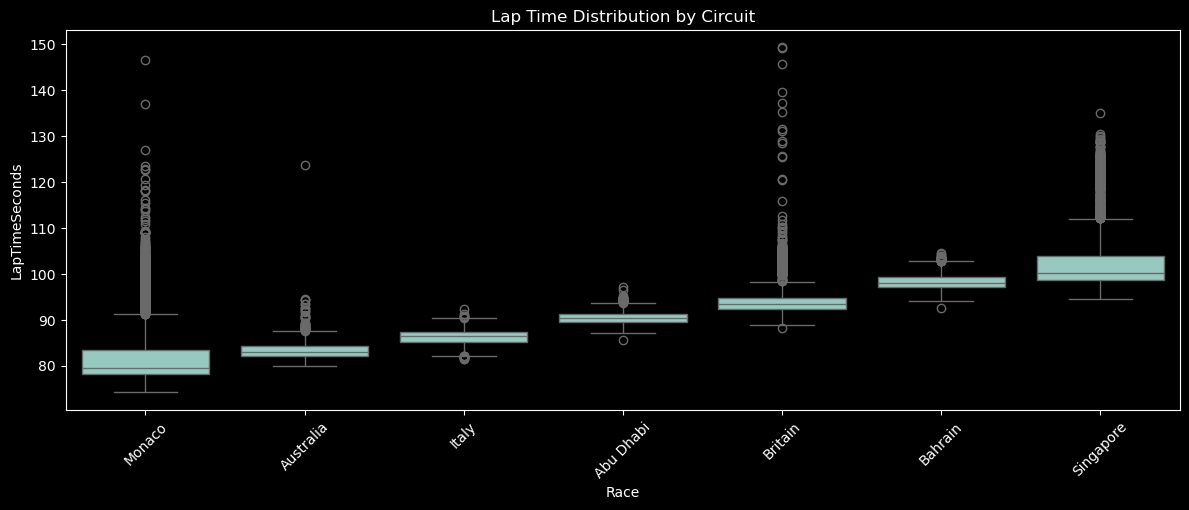

In [15]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby('Race')['LapTimeSeconds'].median().sort_values().index
sns.boxplot(x='Race', y='LapTimeSeconds', data=df, order=order, ax=ax)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Lap Time Distribution by Circuit')
plt.show()

In [16]:
print(df[df['Race'] == 'Monaco']['LapTimeSeconds'].describe())
print(df[df['Race'] == 'Singapore']['LapTimeSeconds'].describe())

count    3456.000000
mean       83.154501
std         8.317065
min        74.165000
25%        78.168000
50%        79.531000
75%        83.376250
max       146.648000
Name: LapTimeSeconds, dtype: float64
count    2743.000000
mean      104.033949
std         8.619484
min        94.486000
25%        98.570500
50%       100.126000
75%       103.955000
max       134.994000
Name: LapTimeSeconds, dtype: float64


In [17]:
df['LapTimeDelta'] = df.groupby(['Driver', 'Race', 'Year'])['LapTimeSeconds'].diff()
print(df['LapTimeDelta'].describe())

count    18989.000000
mean        -0.100448
std          2.131443
min        -54.543000
25%         -0.317000
50%         -0.028000
75%          0.225000
max         40.730000
Name: LapTimeDelta, dtype: float64


In [18]:
print(df['LapTimeDelta'].isnull().sum())

405


In [19]:
df['DegradationFromNew'] = df['LapTimeSeconds'] - df.groupby(['Driver', 'Race', 'Year', 'Stint'])['LapTimeSeconds'].transform('first')
print(df['DegradationFromNew'].describe())

count    19394.000000
mean        -2.730392
std          7.843388
min        -56.436000
25%         -2.182750
50%         -0.439500
75%          0.212000
max         46.880000
Name: DegradationFromNew, dtype: float64


In [20]:
# Key insight: Track evolution outweighs tyre degradation early in stints
# but tyre wear dominates in longer stints. This non-linear relationship
# makes XGBoost ideal over linear models. Both TyreLife and LapNumber
# must be included as features to capture both effects.

In [21]:
le = LabelEncoder()
df['CompoundEncoded'] = le.fit_transform(df['Compound'])

In [22]:
df['DriverEncoded'] = le.fit_transform(df['Driver'])
df['RaceEncoded'] = le.fit_transform(df['Race'])

print(df[['Compound', 'CompoundEncoded', 'Driver', 'DriverEncoded', 'Race', 'RaceEncoded']].head(10))

   Compound  CompoundEncoded Driver  DriverEncoded     Race  RaceEncoded
1      SOFT                3    VER             24  Bahrain            2
2      SOFT                3    VER             24  Bahrain            2
3      SOFT                3    VER             24  Bahrain            2
4      SOFT                3    VER             24  Bahrain            2
5      SOFT                3    VER             24  Bahrain            2
6      SOFT                3    VER             24  Bahrain            2
7      SOFT                3    VER             24  Bahrain            2
8      SOFT                3    VER             24  Bahrain            2
9      SOFT                3    VER             24  Bahrain            2
10     SOFT                3    VER             24  Bahrain            2


In [23]:
print(df.columns.tolist())

['Driver', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'Position', 'IsAccurate', 'Race', 'Year', 'LapTimeSeconds', 'LapTimeDelta', 'DegradationFromNew', 'CompoundEncoded', 'DriverEncoded', 'RaceEncoded']


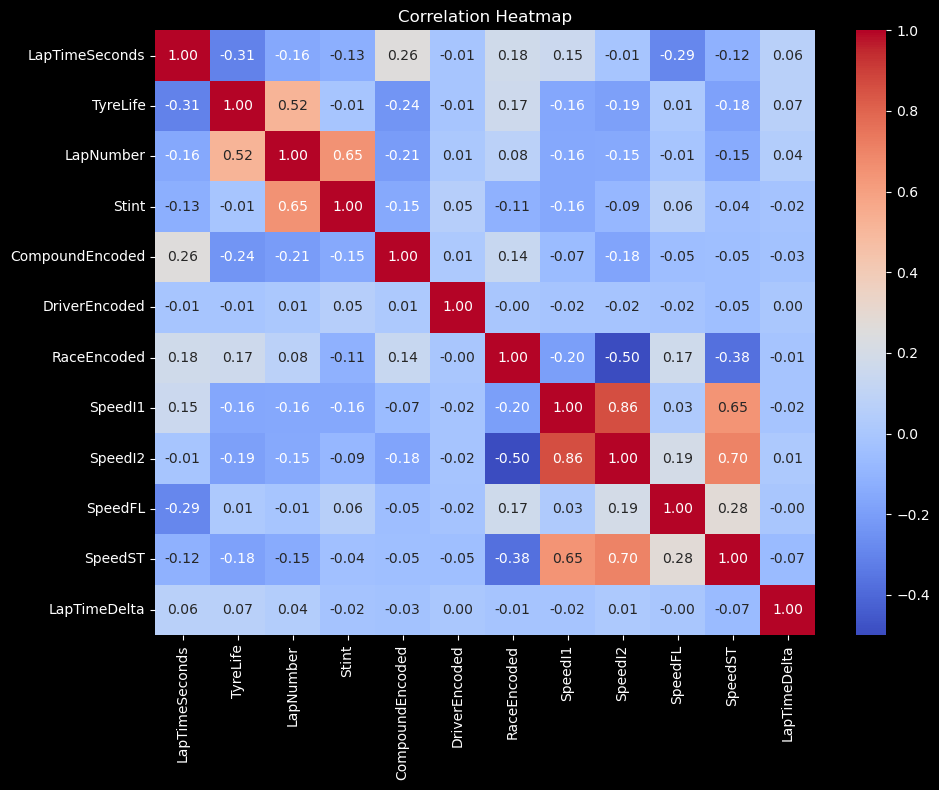

In [27]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = [
    'LapTimeSeconds', 'TyreLife', 'LapNumber', 'Stint',
    'CompoundEncoded', 'DriverEncoded', 'RaceEncoded',
    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
    'LapTimeDelta'
]
corr_matrix = df[numeric_cols].corr()


sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [25]:
print(df[['Driver', 'Race', 'Year', 'Stint', 'TyreLife', 'FreshTyre', 'Compound']].head(60))

   Driver     Race  Year  Stint  TyreLife  FreshTyre Compound
1     VER  Bahrain  2022    1.0       5.0      False     SOFT
2     VER  Bahrain  2022    1.0       6.0      False     SOFT
3     VER  Bahrain  2022    1.0       7.0      False     SOFT
4     VER  Bahrain  2022    1.0       8.0      False     SOFT
5     VER  Bahrain  2022    1.0       9.0      False     SOFT
6     VER  Bahrain  2022    1.0      10.0      False     SOFT
7     VER  Bahrain  2022    1.0      11.0      False     SOFT
8     VER  Bahrain  2022    1.0      12.0      False     SOFT
9     VER  Bahrain  2022    1.0      13.0      False     SOFT
10    VER  Bahrain  2022    1.0      14.0      False     SOFT
11    VER  Bahrain  2022    1.0      15.0      False     SOFT
12    VER  Bahrain  2022    1.0      16.0      False     SOFT
15    VER  Bahrain  2022    2.0       2.0       True     SOFT
16    VER  Bahrain  2022    2.0       3.0       True     SOFT
17    VER  Bahrain  2022    2.0       4.0       True     SOFT
18    VE

In [26]:
df = df.drop(columns=['DegradationFromNew'])
print(df.shape)

(19394, 24)


In [31]:
print(df[['Race', 'CircuitType']].drop_duplicates())

           Race  CircuitType
1       Bahrain            0
1126  Australia            1
2172     Monaco            1
3352    Britain            0
4165      Italy            0
5136  Singapore            1
6081  Abu Dhabi            0


In [30]:
street_circuits = ['Monaco', 'Singapore', 'Australia']
df['CircuitType'] = df['Race'].apply(lambda x: 1 if x in street_circuits else 0)

In [32]:
print(df.columns.tolist())

['Driver', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'Position', 'IsAccurate', 'Race', 'Year', 'LapTimeSeconds', 'LapTimeDelta', 'CompoundEncoded', 'DriverEncoded', 'RaceEncoded', 'TyreCompoundInteraction', 'CircuitType']


In [33]:
features = [
    'TyreLife', 'LapNumber', 'CompoundEncoded', 
    'DriverEncoded', 'RaceEncoded', 'SpeedFL', 
    'LapTimeDelta', 'Stint', 'Year', 
    'CircuitType', 'TyreCompoundInteraction', 'Position'
]

target = 'LapTimeSeconds'

train = df[df['Year'] != 2024]
test = df[df['Year'] == 2024]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 12519
Testing samples: 6875


In [34]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f} seconds")
print(f"R2 Score: {r2:.3f}")

MAE: 2.179 seconds
R2 Score: 0.797


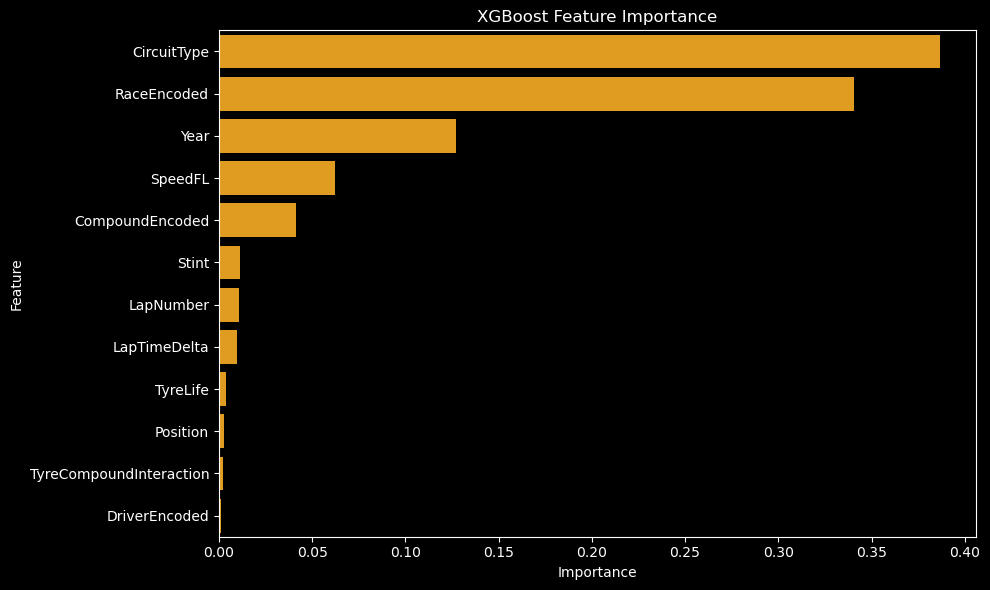

                    Feature  Importance
9               CircuitType    0.386722
4               RaceEncoded    0.340418
8                      Year    0.127334
5                   SpeedFL    0.062091
2           CompoundEncoded    0.041375
7                     Stint    0.011435
1                 LapNumber    0.010820
6              LapTimeDelta    0.009742
0                  TyreLife    0.003848
11                 Position    0.002688
10  TyreCompoundInteraction    0.002391
3             DriverEncoded    0.001135


In [35]:
import pandas as pd
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, ax=ax, color='orange')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

print(importance)

In [36]:
print(df.groupby(['Race', 'Year'])['LapTimeSeconds'].count().unstack())
print("\nTotal per circuit:")
print(df.groupby('Race')['LapTimeSeconds'].count().sort_values(ascending=False))

Year       2022  2023  2024
Race                       
Abu Dhabi  1032  1063   921
Australia   813   769   857
Bahrain     893   914  1024
Britain     674   802   850
Italy       778   878   927
Monaco      846  1423  1187
Singapore   676   958  1109

Total per circuit:
Race
Monaco       3456
Abu Dhabi    3016
Bahrain      2831
Singapore    2743
Italy        2583
Australia    2439
Britain      2326
Name: LapTimeSeconds, dtype: int64


In [37]:
print(df[features].isnull().sum())

TyreLife                     0
LapNumber                    0
CompoundEncoded              0
DriverEncoded                0
RaceEncoded                  0
SpeedFL                      0
LapTimeDelta               405
Stint                        0
Year                         0
CircuitType                  0
TyreCompoundInteraction      0
Position                     0
dtype: int64


In [38]:
df = df.dropna(subset=['LapTimeDelta'])
print(df.shape)

(18989, 26)


In [39]:
df['LapTimeDelta'] = df.groupby(['Driver', 'Race', 'Year'])['LapTimeSeconds'].diff()
df['LapTimeDelta'] = df['LapTimeDelta'].fillna(0)
print(df['LapTimeDelta'].isnull().sum())


0


In [40]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

circuits = ['Monaco', 'Abu Dhabi', 'Bahrain', 
            'Singapore', 'Italy', 'Australia', 'Britain']

models = {}
results = {}

for circuit in circuits:
    # Get circuit specific data
    circuit_data = df[df['Race'] == circuit].copy()
    
    # Temporal split
    train = circuit_data[circuit_data['Year'] != 2024]
    test = circuit_data[circuit_data['Year'] == 2024]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    # Train model
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[circuit] = model
    results[circuit] = {'MAE': mae, 'R2': r2}
    
    print(f"{circuit}: MAE={mae:.3f}s, R2={r2:.3f}")

Monaco: MAE=4.358s, R2=-7.641
Abu Dhabi: MAE=0.849s, R2=-0.120
Bahrain: MAE=1.821s, R2=-1.228
Singapore: MAE=1.760s, R2=-1.647
Italy: MAE=2.098s, R2=-2.299
Australia: MAE=0.707s, R2=0.378
Britain: MAE=3.365s, R2=0.097


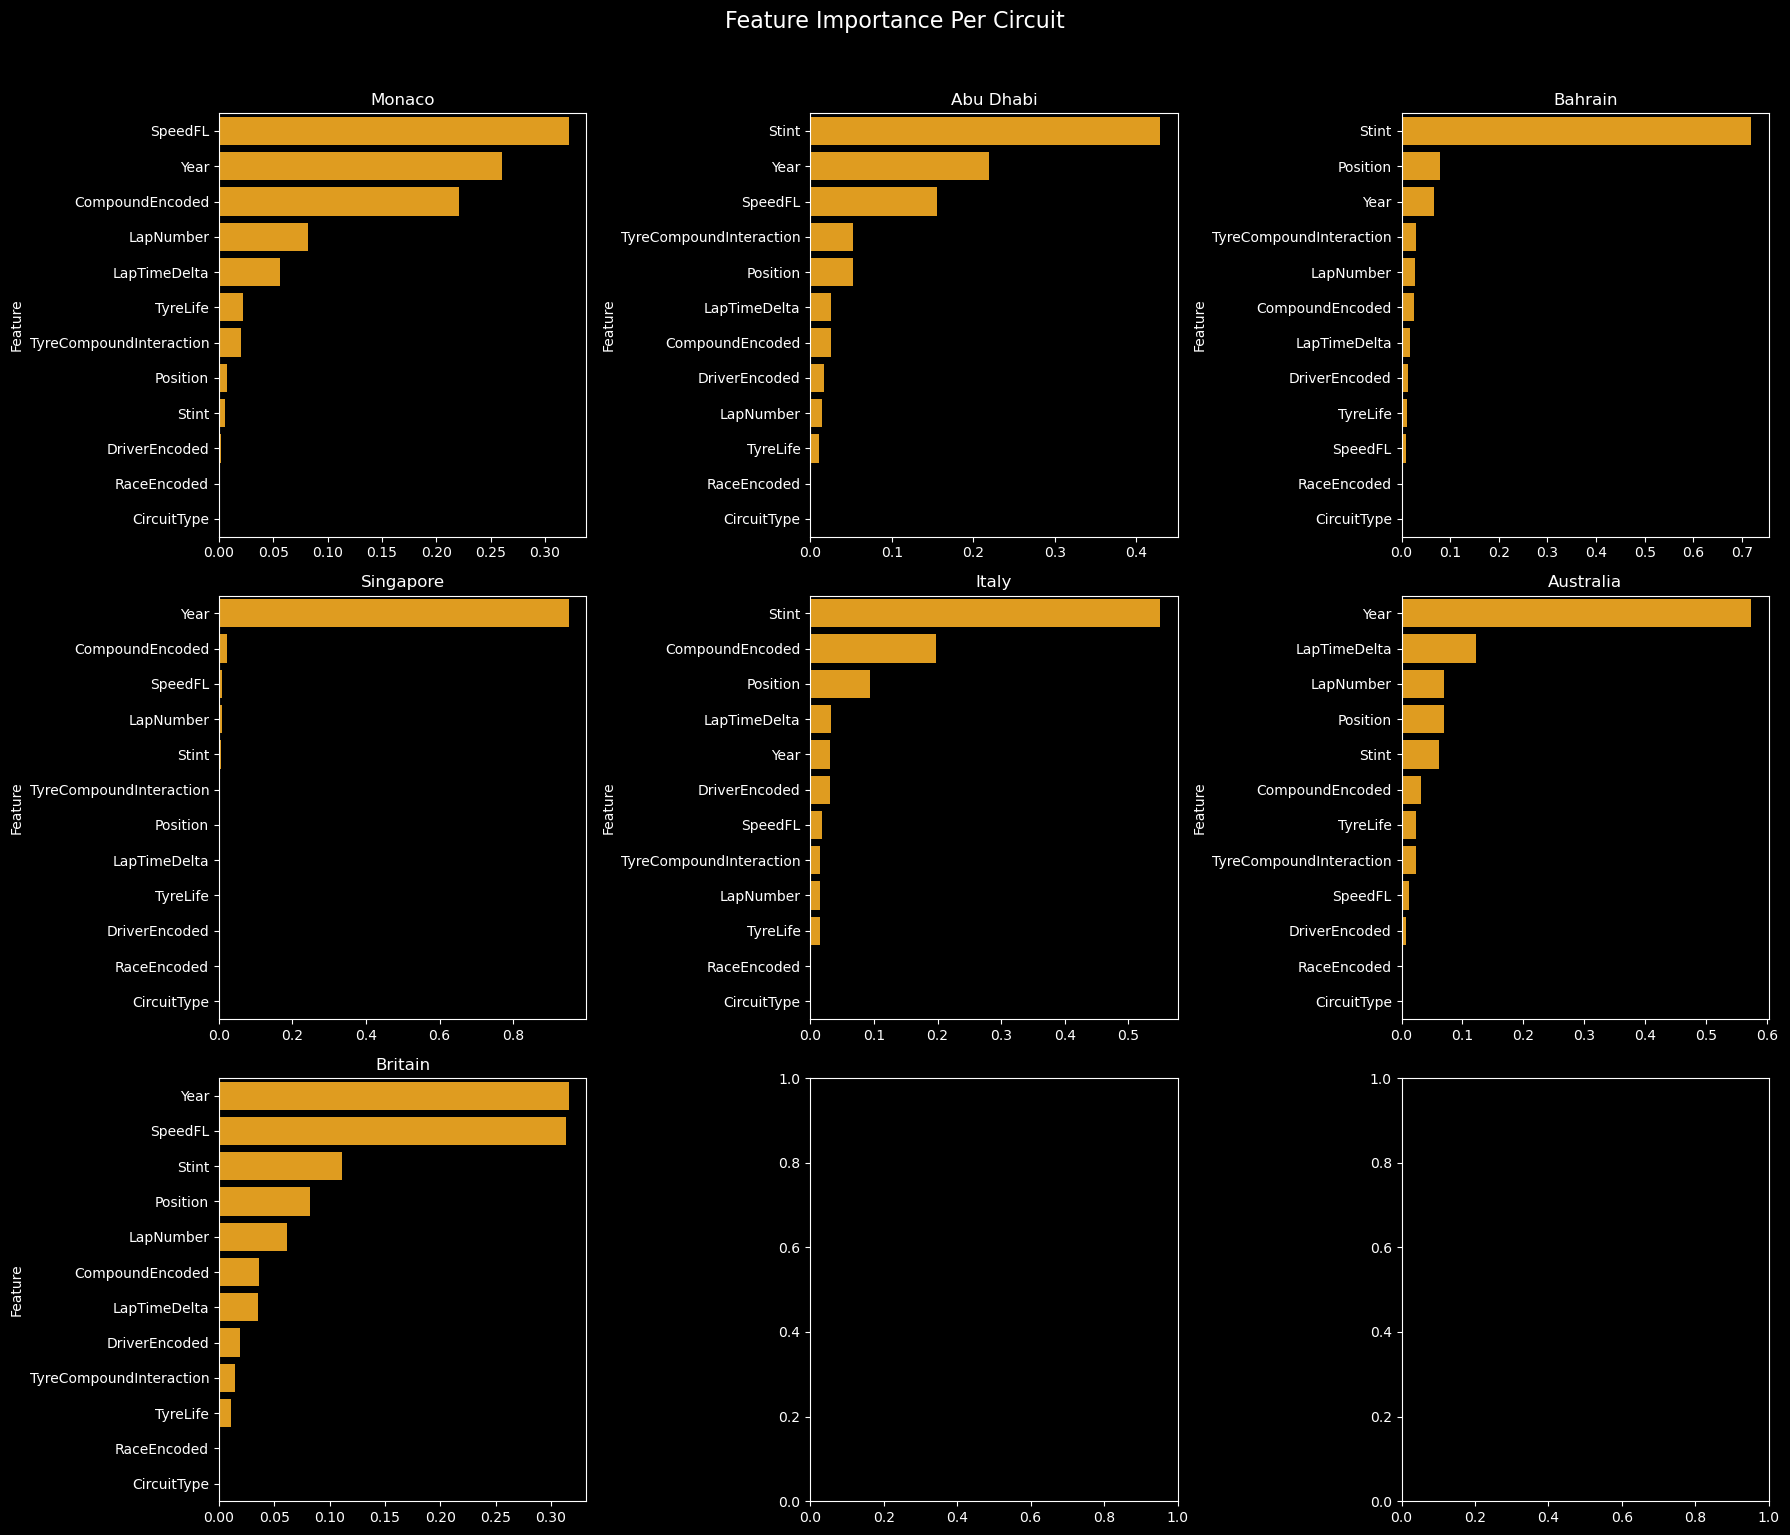

In [41]:
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    importance = pd.DataFrame({
        'Feature': features,
        'Importance': models[circuit].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', 
                data=importance, ax=axes[idx], color='orange')
    axes[idx].set_title(f'{circuit}')
    axes[idx].set_xlabel('')

plt.suptitle('Feature Importance Per Circuit', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
# Normalise lap time against each driver's median in each race
df['LapTimeNormalised'] = df['LapTimeSeconds'] - df.groupby(
    ['Driver', 'Race', 'Year'])['LapTimeSeconds'].transform('median')

# Check what it looks like
print(df['LapTimeNormalised'].describe())

count    18989.000000
mean         0.630337
std          3.987552
min        -15.677500
25%         -0.736000
50%          0.000000
75%          0.725000
max         66.811500
Name: LapTimeNormalised, dtype: float64


In [43]:
target = 'LapTimeNormalised'

for circuit in circuits:
    circuit_data = df[df['Race'] == circuit].copy()
    
    train = circuit_data[circuit_data['Year'] != 2024]
    test = circuit_data[circuit_data['Year'] == 2024]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[circuit] = model
    results[circuit] = {'MAE': mae, 'R2': r2}
    
    print(f"{circuit}: MAE={mae:.3f}s, R2={r2:.3f}")

Monaco: MAE=4.139s, R2=-10.504
Abu Dhabi: MAE=0.324s, R2=0.665
Bahrain: MAE=0.502s, R2=0.654
Singapore: MAE=0.611s, R2=0.363
Italy: MAE=0.591s, R2=0.390
Australia: MAE=0.581s, R2=0.377
Britain: MAE=3.359s, R2=-0.048


In [44]:
# Check Monaco lap time distribution
monaco_data = df[df['Race'] == 'Monaco']
print("Monaco compounds used:")
print(monaco_data.groupby(['Year', 'Compound'])['LapTimeSeconds'].count())

print("\nBritain compounds used:")
britain_data = df[df['Race'] == 'Britain']
print(britain_data.groupby(['Year', 'Compound'])['LapTimeSeconds'].count())

Monaco compounds used:
Year  Compound    
2022  HARD            246
      INTERMEDIATE     75
      MEDIUM          287
      SOFT              6
      WET             212
2023  HARD            621
      INTERMEDIATE    376
      MEDIUM          339
      SOFT             27
      WET              40
2024  HARD            755
      MEDIUM          384
      SOFT             32
Name: LapTimeSeconds, dtype: int64

Britain compounds used:
Year  Compound    
2022  HARD            151
      MEDIUM          341
      SOFT            165
2023  HARD            114
      MEDIUM          424
      SOFT            244
2024  HARD             38
      INTERMEDIATE    188
      MEDIUM          449
      SOFT            156
Name: LapTimeSeconds, dtype: int64


In [45]:
dry_compounds = ['SOFT', 'MEDIUM', 'HARD']
df = df[df['Compound'].isin(dry_compounds)]
print(df.shape)

(17719, 27)


In [46]:
target = 'LapTimeNormalised'

for circuit in circuits:
    circuit_data = df[df['Race'] == circuit].copy()
    
    train = circuit_data[circuit_data['Year'] != 2024]
    test = circuit_data[circuit_data['Year'] == 2024]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[circuit] = model
    results[circuit] = {'MAE': mae, 'R2': r2}
    
    print(f"{circuit}: MAE={mae:.3f}s, R2={r2:.3f}")

Monaco: MAE=4.005s, R2=-9.157
Abu Dhabi: MAE=0.324s, R2=0.665
Bahrain: MAE=0.502s, R2=0.654
Singapore: MAE=0.570s, R2=0.472
Italy: MAE=0.591s, R2=0.390
Australia: MAE=0.581s, R2=0.377
Britain: MAE=1.348s, R2=0.464


In [47]:
monaco_data = df[df['Race'] == 'Monaco']
print(monaco_data.groupby(['Year', 'Compound'])['LapTimeNormalised'].describe())

               count      mean       std     min       25%      50%       75%  \
Year Compound                                                                   
2022 HARD      246.0  0.589675  6.579783 -3.6555 -2.113375 -1.01575  0.561000   
     MEDIUM    287.0 -0.226392  6.154470 -5.4830 -2.242000 -1.47400 -0.004000   
     SOFT        6.0 -3.689333  5.487835 -6.7175 -6.281750 -6.03450 -4.792750   
2023 HARD      621.0 -0.079890  3.338130 -3.5535 -1.224000 -0.57100  0.084500   
     MEDIUM    339.0  0.076409  3.039626 -3.4340 -0.971250 -0.46200  0.090500   
     SOFT       27.0 -1.032426  3.051006 -3.1005 -2.699500 -1.77750 -0.859000   
2024 HARD      755.0 -0.304375  1.634374 -5.4195 -1.494000 -0.04900  0.555000   
     MEDIUM    384.0  0.197802  1.889135 -5.3240 -0.638875  0.27800  1.295625   
     SOFT       32.0 -1.640563  1.646724 -6.2280 -2.474750 -1.41050 -0.960500   

                   max  
Year Compound           
2022 HARD      43.9420  
     MEDIUM    44.6635  
     SOF

In [48]:
# Remove laps more than 10 seconds from driver median - clear outliers
df = df[df['LapTimeNormalised'].abs() < 10]
print(df.shape)
print(df.groupby('Race')['LapTimeNormalised'].describe())

(17647, 27)
            count      mean       std     min       25%     50%       75%  \
Race                                                                        
Abu Dhabi  2957.0  0.034610  0.885372 -4.4035 -0.440500  0.0000  0.625000   
Australia  2376.0  0.047534  1.232560 -3.9460 -0.787000  0.0000  0.643875   
Bahrain    2771.0 -0.008929  1.247937 -5.1330 -0.834000  0.0000  0.827000   
Britain    2063.0 -0.195156  1.423105 -4.0930 -1.031500 -0.0630  0.414500   
Italy      2524.0  0.029455  0.780375 -2.7735 -0.370125  0.0000  0.470000   
Monaco     2660.0 -0.409096  1.793180 -6.7175 -1.486250 -0.4245  0.389750   
Singapore  2296.0 -0.764480  2.378018 -9.8820 -1.076000 -0.1100  0.460000   

              max  
Race               
Abu Dhabi  5.1630  
Australia  9.1725  
Bahrain    3.9460  
Britain    9.9040  
Italy      4.6720  
Monaco     9.8870  
Singapore  7.7335  


In [49]:
for circuit in circuits:
    circuit_data = df[df['Race'] == circuit].copy()
    
    train = circuit_data[circuit_data['Year'] != 2024]
    test = circuit_data[circuit_data['Year'] == 2024]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[circuit] = model
    results[circuit] = {'MAE': mae, 'R2': r2}
    
    print(f"{circuit}: MAE={mae:.3f}s, R2={r2:.3f}")

Monaco: MAE=1.906s, R2=-0.667
Abu Dhabi: MAE=0.324s, R2=0.665
Bahrain: MAE=0.502s, R2=0.654
Singapore: MAE=0.570s, R2=0.470
Italy: MAE=0.591s, R2=0.390
Australia: MAE=0.578s, R2=0.369
Britain: MAE=1.119s, R2=0.450


In [50]:
target = 'LapTimeNormalised'

features = [
    'TyreLife', 'LapNumber', 'CompoundEncoded', 
    'DriverEncoded', 'RaceEncoded', 'SpeedFL', 
    'LapTimeDelta', 'Stint', 'Year', 
    'CircuitType', 'TyreCompoundInteraction', 'Position'
]

train = df[df['Year'] != 2024]
test = df[df['Year'] == 2024]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

combined_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

combined_model.fit(X_train, y_train)
y_pred = combined_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Combined Model: MAE={mae:.3f}s, R2={r2:.3f}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Combined Model: MAE=0.708s, R2=0.350
Training samples: 11112
Testing samples: 6535


In [51]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': combined_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

                    Feature  Importance
8                      Year    0.285151
4               RaceEncoded    0.127285
1                 LapNumber    0.122877
9               CircuitType    0.107462
7                     Stint    0.086435
6              LapTimeDelta    0.083948
2           CompoundEncoded    0.059634
10  TyreCompoundInteraction    0.045560
5                   SpeedFL    0.028901
0                  TyreLife    0.023322
11                 Position    0.017581
3             DriverEncoded    0.011844


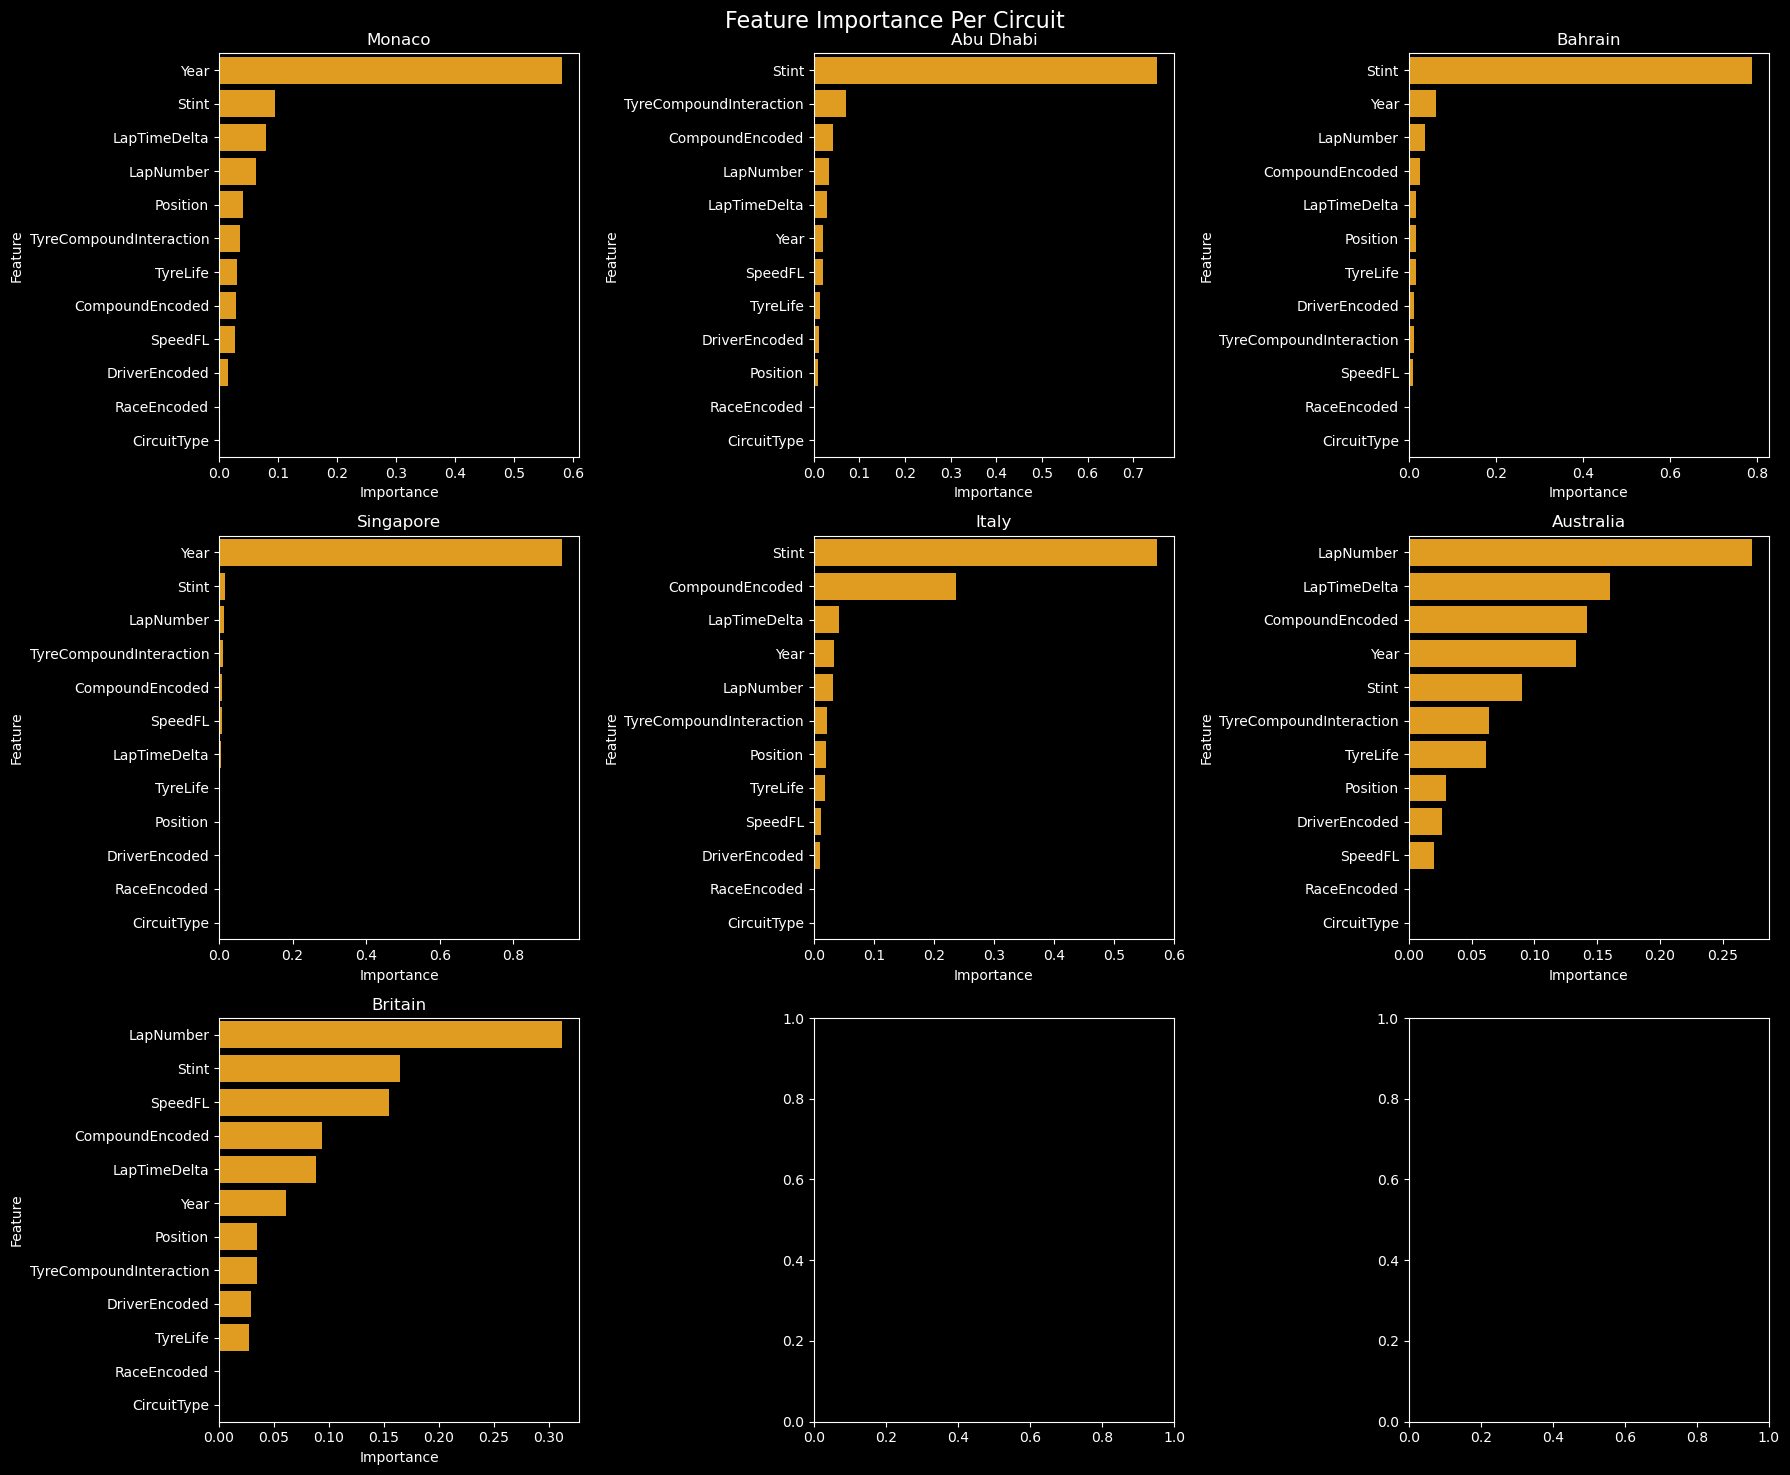

In [52]:
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    importance = pd.DataFrame({
        'Feature': features,
        'Importance': models[circuit].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', 
                data=importance, ax=axes[idx], color='orange')
    axes[idx].set_title(f'{circuit}')

plt.suptitle('Feature Importance Per Circuit', fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
df['TeamEncoded'] = LabelEncoder().fit_transform(df['Team'])

Monaco: MAE=1.730s, R2=-0.457
Abu Dhabi: MAE=0.324s, R2=0.692
Bahrain: MAE=0.455s, R2=0.702
Singapore: MAE=0.870s, R2=-0.527
Italy: MAE=0.584s, R2=0.400
Australia: MAE=0.541s, R2=0.422
Britain: MAE=1.113s, R2=0.456
Combined Model: MAE=1.113s, R2=0.456
Training samples: 1439
Testing samples: 624


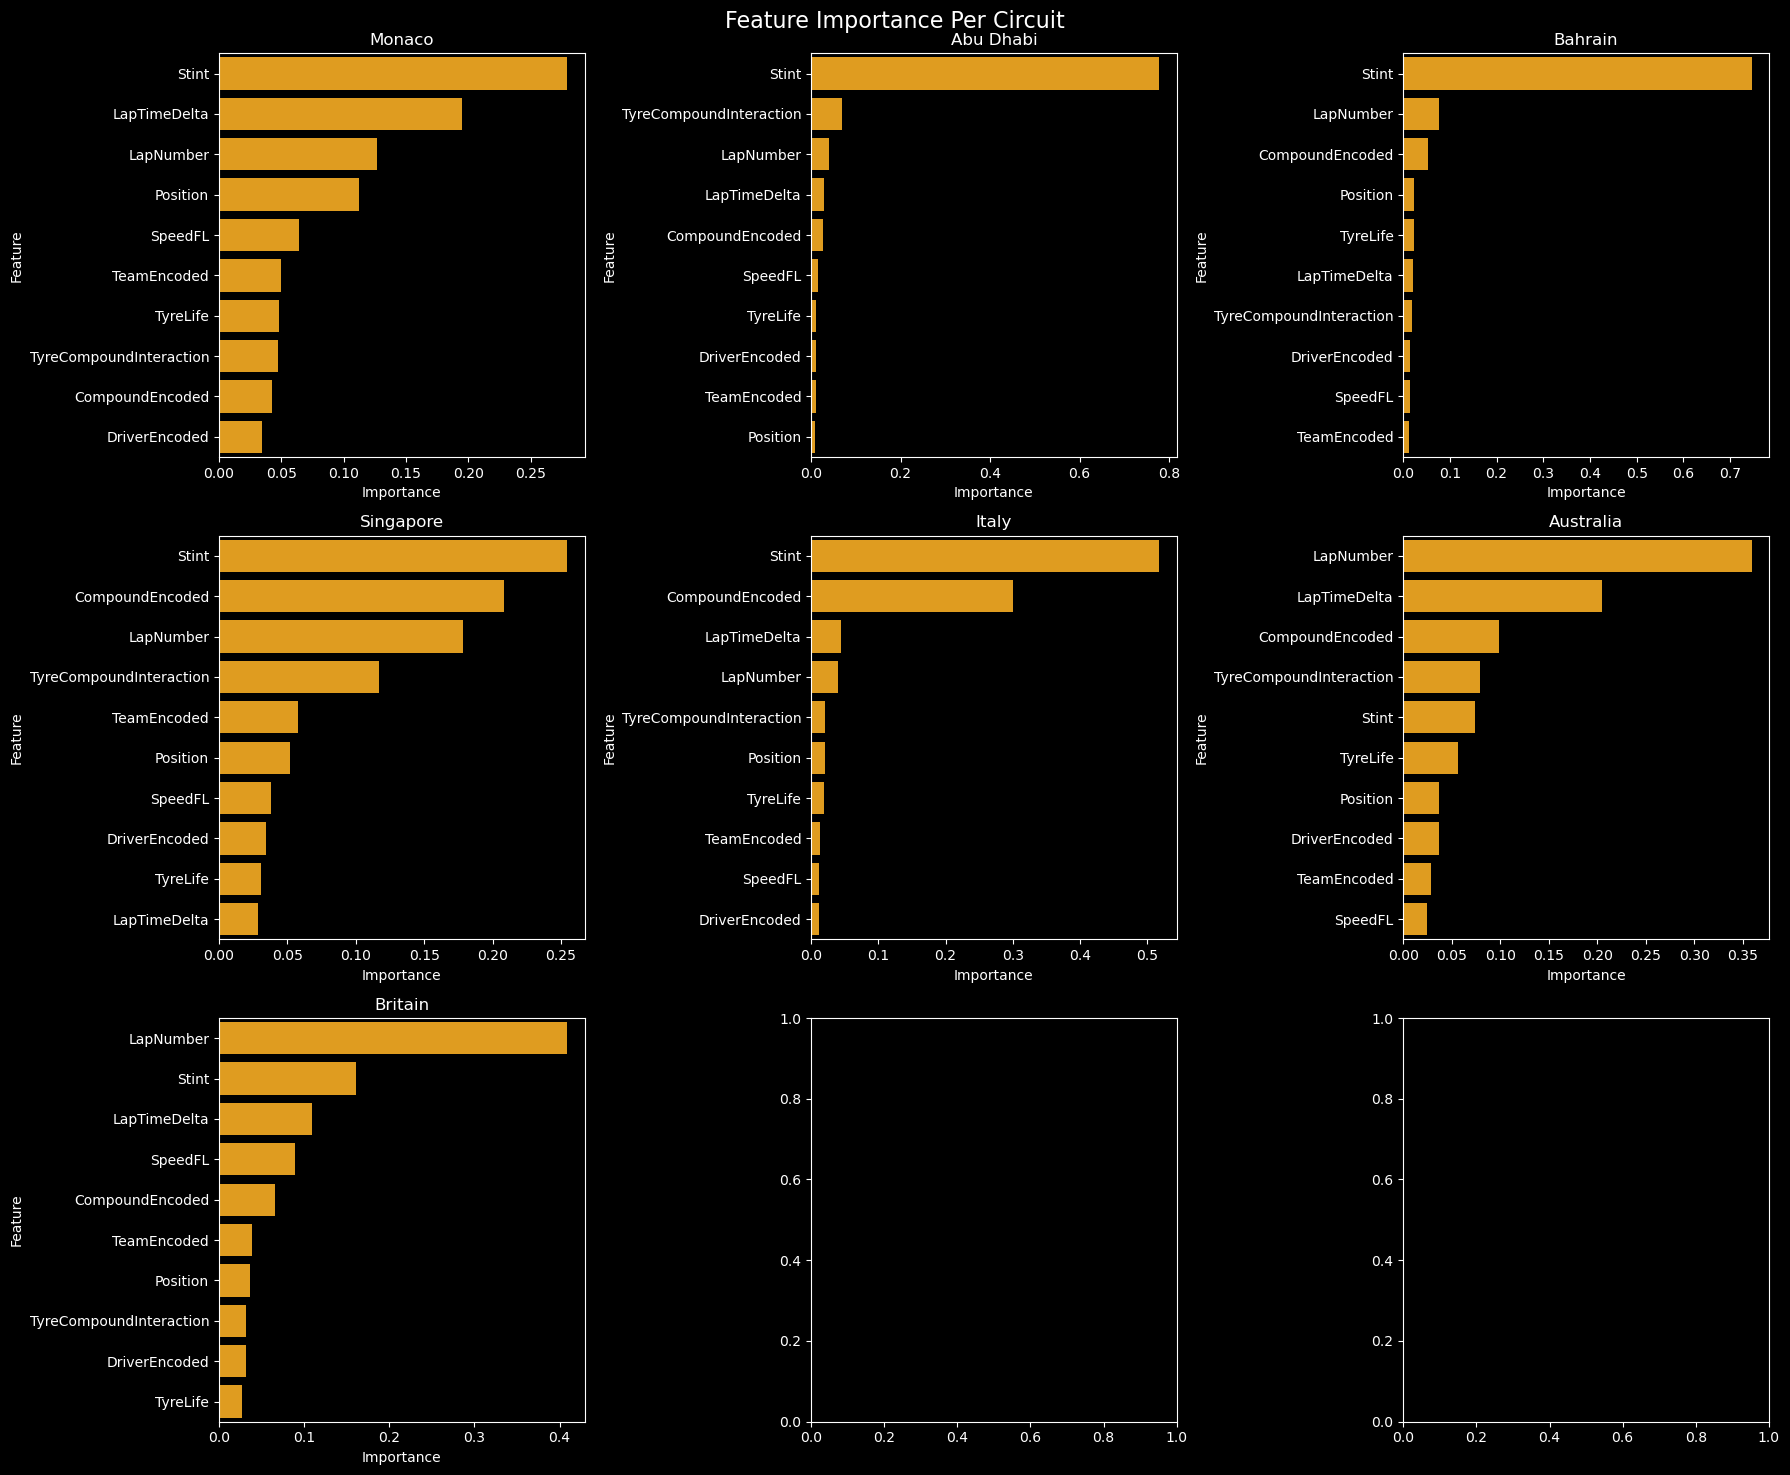

In [55]:
features = [
    'TyreLife', 'LapNumber', 'CompoundEncoded', 
    'DriverEncoded', 'TeamEncoded', 'SpeedFL', 
    'LapTimeDelta', 'Stint', 'Position', 
    'TyreCompoundInteraction'
]
target = 'LapTimeNormalised'

for circuit in circuits:
    circuit_data = df[df['Race'] == circuit].copy()
    
    train = circuit_data[circuit_data['Year'] != 2024]
    test = circuit_data[circuit_data['Year'] == 2024]
    
    X_train = train[features]
    y_train = train[target]
    X_test = test[features]
    y_test = test[target]
    
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    models[circuit] = model
    results[circuit] = {'MAE': mae, 'R2': r2}
    
    print(f"{circuit}: MAE={mae:.3f}s, R2={r2:.3f}")
print(f"Combined Model: MAE={mae:.3f}s, R2={r2:.3f}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


plt.style.use('dark_background')
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, circuit in enumerate(circuits):
    importance = pd.DataFrame({
        'Feature': features,
        'Importance': models[circuit].feature_importances_
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', 
                data=importance, ax=axes[idx], color='orange')
    axes[idx].set_title(f'{circuit}')

plt.suptitle('Feature Importance Per Circuit', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
cd ~/Desktop/Formula1 && git add . && git commit -m "improved per circuit models - removed Year bias, added TeamEncoded" && git push